### Lecture Notes: Introduction to Hypothesis Testing

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html)

**Recommended Readings:**
- [Assessing a Model](https://www.inferentialthinking.com/chapters/11/1/Assessing_a_Model.html)
- [Decisions and P-value](https://www.inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html)
- [A/B Testing](https://www.inferentialthinking.com/chapters/12/1/AB_Testing.html)
- [Testing two proportions](https://www.inferentialthinking.com/chapters/12/2/Causality.html)

### Models

A model in data science, is a set of assumptions about data. Often, models include assumptions about chance processes used to generate data. Data scientists often have to decide whether or not a model is good.

### Hypotheses: Null hypothesis vs. alternative hypothesis

A hypothesis is a statement to represent a view of the world.

Null hypothesis and alternative hypothesis are two competing hypotheses.

The null hypothesis says that the data were generated at random under clearly specified assumptions about the randomness. The word “null” reinforces the idea that if the data look different from what the null hypothesis predicts, the difference is due to nothing but chance. In other word, the null hypothesis is the baseline assumption.

From a practical perspective of data science and statistics, the null hypothesis is a **model** (a set of assumptions about data) under which you can simulate data.

The alternative hypothesis says that some reason other than chance made the data differ from the predictions of the model in the null hypothesis. In other word, the alternative hypothesis is the opposite statement to the null hypothesis.

However, the alternative doesn’t say how or why the model isn’t good. It just says the model isn’t good.


In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
students = Table().read_table('student_data.csv')


### Hypothesis Testing Based on Simulations

1. State the null and alternative hypothesis
2. Pick a test statistic
3. Simulate the sampling distribution of the test statistic, under the null hypothesis (model)
4. Draw conclusion based on the results of the random sampling distribution simulation and empirical distributions. 


### Test Statistic

The test statistic is a single number that is computed from a dataset. The dataset can be generated from an empirical observation (real) or a theoretical random simulation (fake). The test statistic (the single number) can a mean, median, standard deviation, a proportion, a percentage, categories comparison, simple a number out of a simple size and total variation distance (TVD) for multiple categories. The test statistic can be used to guide making decision.

Test statistic is typically used to make decision on null vs alternative hypothese.

1. We have learned using `sample_proportions()` from datascience library to perform random sampling to compute a statistic.

2. `sample_proportions()` returns an array.

3. We have also learned to start with simulating one value of the statistic and then use a `for`-loop to simulate multiple values of the statistic.

#### Single Category & Test Statistic 

#### Swain v.s. Alabama

In the [Swain v.s. Alabama (1965) case](https://inferentialthinking.com/chapters/11/1/assessing-a-model/#jury-selection), Robert Swain believes that the jury panel that convicted him under-represented the population of eligible jurors, among which 26% were black. In reality at that time, in the jury panel of 100 jurors, only 8 were black (empirical data/distribution). The Supreme court opinion stated "the overall percentage disparity has been small". 

What are the null and alternative hypotheses? 

**Null hypothesis**: the percentage of black jurors in the jury panels is 26%

**Alternative hypothesis**: the percentage of black jurors in the jury panels is less than 26%

**Test statistic**: number of black jurors in a panel of 100


In [2]:
# simulate one value of the sampling distribution of the test statistic, 
#   under the null hypothesis (model)
sample_size = 100
proportions = make_array(0.26, 0.74)
sample_proportions(sample_size, proportions)
# To get the black proportion
sample_proportions(sample_size, proportions).item(0)
# To get number of the black in the sample size
sample_proportions(sample_size, proportions).item(0) * 100

30.0

In [3]:
# simulate many values of the sampling distribution of the test statistic, 
#   under the null hypothesis (model)
def sampling_distribution_black(sample_size, proportion, repeats):
    results = make_array()
    proportions = make_array(proportion, 1-proportion)   
    for i in np.arange(repeats):
        results = np.append(results, sample_proportions(sample_size, proportions).item(0)*sample_size)
    return results

In [4]:
# check the max and min
repeats = 100000
simulated_statistic_results = sampling_distribution_black(100, 0.26, repeats)
(simulated_statistic_results.max(), simulated_statistic_results.min())

(45.0, 9.0)

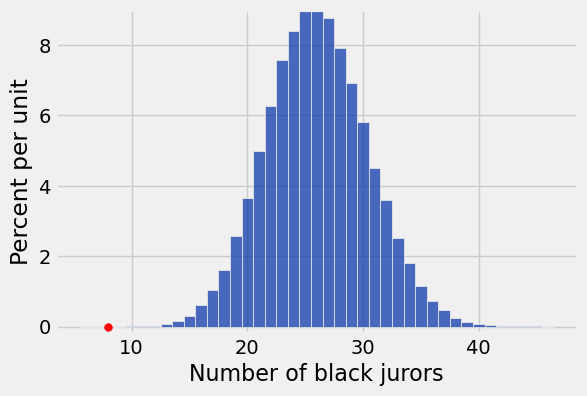

In [5]:
Table().with_column('Number of black jurors', simulated_statistic_results).hist(bins=np.arange(5.5, 47.5, 1))

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

What is the overall conclusion from the hypothesis test?

Since the observed statistic, which is the number of black jurors in a panel of 100, is far out in the tail of the random sampling distribution, the data provides strong evidence against the null hypothesis. 

That means there is a good evidence for the under-representation of black jurors.

In [6]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
observed_statistic_value = 8  # 8 black jurors out or 100
p_value = np.count_nonzero(simulated_statistic_results < observed_statistic_value) / repeats
p_value

0.0

Consider that instead of having 26% eligible black jurors in the population, there was 12% of the eligible jurors are black.

If we re-run the simulation based on this new null hypothesis (model). 

In [7]:
# check the max and min
simulated_statistic_results = sampling_distribution_black(100, 0.12, 100000)
(simulated_statistic_results.max(), simulated_statistic_results.min())

(28.000000000000004, 0.0)

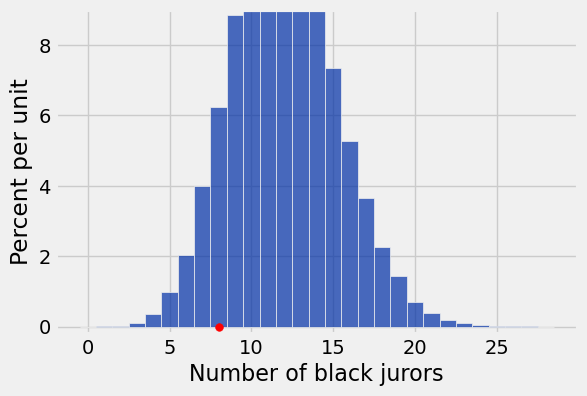

In [8]:
Table().with_column('Number of black jurors', simulated_statistic_results).hist(bins=np.arange(-0.5, 29.5, 1))

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

Any change in the overall conclusion?

Since the observed test statistic is inside the main body of the random sampling distribution, the data is consistent with the null hypothesis. There is not enough evidence for the under-representation.

In [9]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
observed_statistic_value = 8  # 8 black jurors out or 100
p_value = np.count_nonzero(simulated_statistic_results < observed_statistic_value) / repeats
p_value

0.074999999999999997

#### Multiple Categories and Test Statistic

#### Total Variation Distance (TVD)

Total variation distance can be a test statistic, and TVD is particularly designed for analyzing multiple categories (3 or more). 

TVD is a distance between two distributions. It is computed by taking the absolute value of each distance, adding up all distances and dividing the total by 2.

Total Variation Distance between the observed empirical proportions and the theoretical model proportions defined by the null hypothesis.

In other words, TVD is all about comparing the proportions among multiple categories.

In general, the total variation distance between two distributions measures how close the distributions are. The larger the TVD, the more different the two distributions appear.



### Example 1: loaded die

A gambler at a casino observed a die that was rolled 120 times and noticed that the number of rolls were not perfectly even. Specifically, he counted the following frequencies for each face of the die: (18, 21, 19, 23, 24, 15). He suspects the die may be loaded.

There are 6 categories because there are 6 faces.

What are the null and alternative hypotheses and the test statistic? 

**Null hypothesis**: the die is fair (each face has 1/6 chance)

**Alternative hypothesis**: the die is not fair (at least one face is not 1/6)

**Test statistic**: total variation distance (TVD) between observed empirical die rolling proportions and the theoretical model proportions defined by the null hypothesis (each face has 1/6 chance).

In [10]:
die = Table().with_columns(
    'Face', make_array(1, 2, 3, 4, 5, 6),
    'Fair', make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6),
    'Loaded', make_array(18/120, 21/120, 19/120, 23/120, 24/120, 15/120)
)

die

Face,Fair,Loaded
1,0.166667,0.15
2,0.166667,0.175
3,0.166667,0.158333
4,0.166667,0.191667
5,0.166667,0.2
6,0.166667,0.125


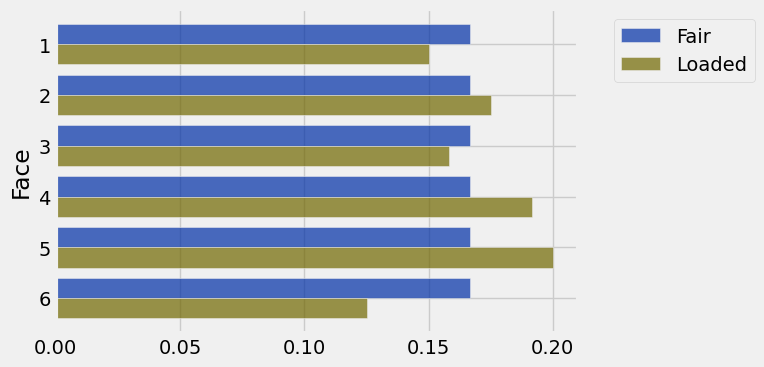

In [11]:
# use a bar chart to visualize the difference
die.barh("Face")

#### Comparison with Fair Die Rolled at Random

In [12]:
# simulate one random selection
fair_die_proportions = die.column("Fair")
sample_proportions_distribution = sample_proportions(120, fair_die_proportions)
loaded_and_random = die.with_columns('Random Sample Roll', sample_proportions_distribution)
loaded_and_random

Face,Fair,Loaded,Random Sample Roll
1,0.166667,0.15,0.225
2,0.166667,0.175,0.125
3,0.166667,0.158333,0.15
4,0.166667,0.191667,0.175
5,0.166667,0.2,0.158333
6,0.166667,0.125,0.166667


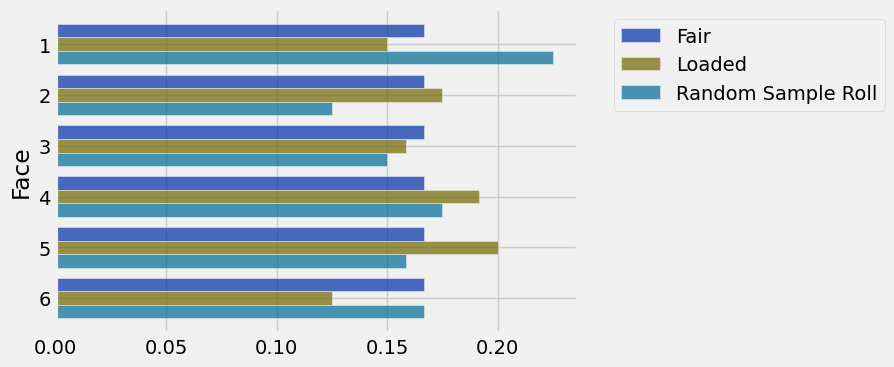

In [13]:
loaded_and_random.barh('Face')

#### Use TVD as Test Statistic and Calculate the Empirical Observed TVD Value

1. compute the differences of the fair die and the loaded die
2. take the the absolute value of each differences
3. add up all the differences and divide the total by 2


In [14]:
# compute the differences of the fair die and the loaded die
diffs = die.column("Fair") - die.column("Loaded")

# append to the table
die_with_diffs = die.with_column(
    'Difference', diffs
)
die_with_diffs

Face,Fair,Loaded,Difference
1,0.166667,0.15,0.0166667
2,0.166667,0.175,-0.00833333
3,0.166667,0.158333,0.00833333
4,0.166667,0.191667,-0.025
5,0.166667,0.2,-0.0333333
6,0.166667,0.125,0.0416667


In [15]:
# take the the absolute value of each difference and append to the table

die_with_diffs = die_with_diffs.with_column(
    'Absolute Difference', np.abs(die_with_diffs.column('Difference'))
)

die_with_diffs

Face,Fair,Loaded,Difference,Absolute Difference
1,0.166667,0.15,0.0166667,0.0166667
2,0.166667,0.175,-0.00833333,0.00833333
3,0.166667,0.158333,0.00833333,0.00833333
4,0.166667,0.191667,-0.025,0.025
5,0.166667,0.2,-0.0333333,0.0333333
6,0.166667,0.125,0.0416667,0.0416667


In [16]:
# add up all the differences and divide the total by 2
observed_tvd_value = die_with_diffs.column('Absolute Difference').sum() / 2
observed_tvd_value

print(f"The empirical observed TVD between the fair and loaded die is {observed_tvd_value}")

The empirical observed TVD between the fair and loaded die is 0.06666666666666668


In [17]:
# we can also put the steps for computing TVD in a function

def tvd(distance1, distance2):
    return sum(np.abs(distance1 - distance2))/ 2

In [18]:
fair_die_proportions = die.column("Fair")
observed_die_proportions = die.column("Loaded")

# compute the observed tvd value by calling the function
observed_tvd_value = tvd(fair_die_proportions, observed_die_proportions)
observed_tvd_value

0.06666666666666668

#### Simulating the TVD, the test statistic under the model

1. 120 is the sample size because 120 rolls were done in the empirical observed data
2. use `sample_proportions()` function to generate random sample distribution
3. the fair_die_proportions is 1/6 chance for each face

In [19]:
# the fair_die_proportions is in the "Fair" column
die

Face,Fair,Loaded
1,0.166667,0.15
2,0.166667,0.175
3,0.166667,0.158333
4,0.166667,0.191667
5,0.166667,0.2
6,0.166667,0.125


In [20]:
# sample size is 120, what are the sample proportions distribution out of 120 sample size?
sample_proportions_distribution = sample_proportions(120, fair_die_proportions)

# one TVD between the distributions in the random sample and the fair die
tvd(sample_proportions_distribution, fair_die_proportions)

0.06666666666666668

In [21]:
# simulate the test statistic TVDs under the nully hypothesis 
#  (tvd between the distributions in the random sample and the fair die)

simulated_tvds_results = make_array()
repeats = 10000
for i in np.arange(repeats):
    sample_proportions_distribution = sample_proportions(120, fair_die_proportions)
    test_statistic_tvd = tvd(sample_proportions_distribution, fair_die_proportions)
    simulated_tvds_results = np.append(simulated_tvds_results, test_statistic_tvd)

(simulated_tvds_results.max(), simulated_tvds_results.min())


(0.19999999999999996, 0.0083333333333333315)

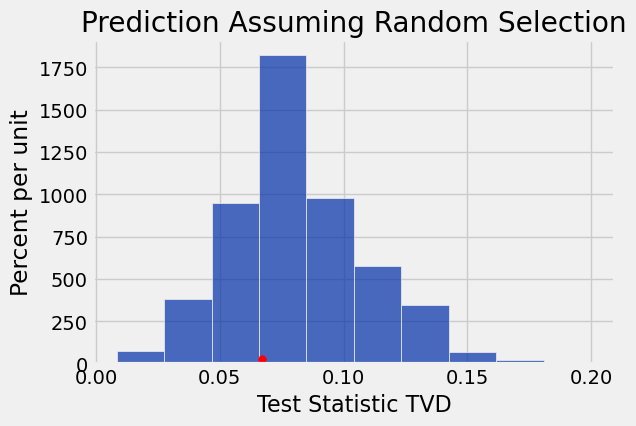

In [22]:
Table().with_column('Test Statistic TVD', simulated_tvds_results).hist()

# Plotting parameters; you can ignore this code
plots.title('Prediction Assuming Random Selection')
plots.scatter(0.067, 0.3, color='red', s=30);

Since the observed test statistic (the TVD between the empirical die-rolling proportions and the fair die model proportions) is inside the main body of the random sampling distribution, the data is consistent with the null hypothesis. The die may be fair.

In [23]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
p_value = np.count_nonzero(simulated_tvds_results >= observed_tvd_value) / repeats
p_value

0.66149999999999998

### Example 2: smartphone OS adoption

Smartphone OS categories: Android, iOS and other

**Null hypothesis**: college students follow the global smartphone market share 

- model: 0.35 for Android, 0.64 for iOS and 0.01 for other

**Alternative hypothesis**: college students don't follow the global smartphone market share 

- model: 0.71 for Android, 0.28 for iOS and 0.01 for other
- 500 students were interviewed

**Test statistic**: TVD between the empirical student data on smartphone OS adoption proportions and the global smartphone marke share.


In [24]:
# define the categorical distribution model and put it in a table 
OS_categories = make_array('Android', 'iOS', 'Other')
global_OS_proportions = make_array(0.71, 0.28, 0.01)
observed_OS_proportions = make_array(0.35, 0.64, 0.01)

model_tbl = Table().with_columns(
    'OS', OS_categories,
    'Global Market Share', global_OS_proportions,
    'Student Adoption', observed_OS_proportions
)

model_tbl

OS,Global Market Share,Student Adoption
Android,0.71,0.35
iOS,0.28,0.64
Other,0.01,0.01


In [25]:
# create a function to compute TVD
def tvd(distance1, distance2):
    return sum(np.abs(distance1 - distance2))/ 2

In [26]:
# compute the observed tvd value
observed_tvd_value = tvd(global_OS_proportions, observed_OS_proportions)
print(f"The TVD between the empirical student data on smartphone OS adoption proportions and \nthe global smartphone market share is {observed_tvd_value:.4f}\n")

The TVD between the empirical student data on smartphone OS adoption proportions and 
the global smartphone market share is 0.3600



In [27]:
# simulate the test statistic TVDs under the nully hypothesis
#   (tvd between the distributions in the random sample and the global smartphone market share)
simulated_tvds_results = make_array()
# 500 students were interviewed
sample_size = 500
repeats = 10000

for i in np.arange(repeats):
    # draw a random sample of 500 students based on the global smartphone market share proportions
    sample_proportions_distribution = sample_proportions(sample_size, global_OS_proportions)
    # compute the TVD between the distribution in the random sample and the global smartphone market share
    test_statistic_tvd = tvd(sample_proportions_distribution, global_OS_proportions)
    simulated_tvds_results = np.append(simulated_tvds_results, test_statistic_tvd)

# check the max and min
(simulated_tvds_results.max(), simulated_tvds_results.min())

(0.077999999999999958, 0.0)

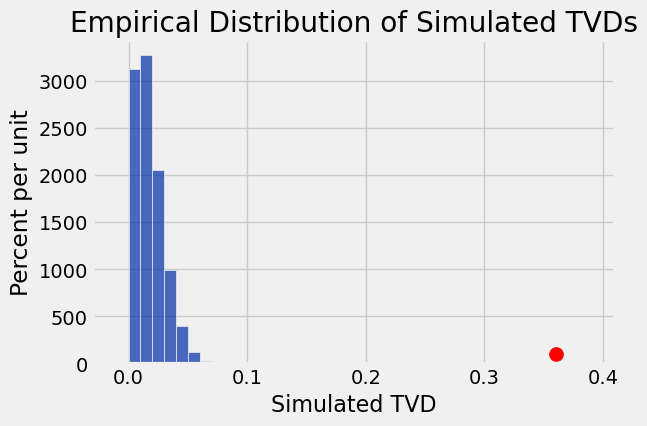

In [28]:
Table().with_column('Simulated TVD', simulated_tvds_results).hist(bins=np.arange(-0.01, 0.4, 0.01))

plots.scatter(0.36, 1, color='red', s=100)
plots.title("Empirical Distribution of Simulated TVDs")
plots.show()

Since the observed test statistic (the TVD between the empirical student data on smartphone OS adoption proportions and the global smartphone market share) is far out in the tail of the random sampling distribution, the data provides strong evidence against the null hypothesis. This allows us to conclude that the college students don't follow the global smartphone market share distribution.

In [29]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
p_value = np.count_nonzero(simulated_tvds_results >= observed_tvd_value) / repeats
p_value

0.0

### Functions to Simulate TVD Test Statistic Under a Hypothesis Model

In [30]:
def tvd(distance1, distance2):
    return sum(np.abs(distance1 - distance2))/ 2

def tvd_simulation(sample_size, model_proportions, repeats):
    simulated_tvds = make_array()
    for i in np.arange(repeats):
        # draw a random sample of X based on a hypothesis model
        sample_proportions_distribution = sample_proportions(sample_size, model_proportions)
        # compute the TVD between the distribution in the random sample and the the hypothesis model
        test_statistic_tvd = tvd(sample_proportions_distribution, model_proportions)
        simulated_tvds = np.append(simulated_tvds, test_statistic_tvd)
    return simulated_tvds

### Example 3: M&M

M&M candy colors: Blue, Orange, Green, Yellow, Red, Brown

**Null hypothesis**: The color proportions of M&M candy bags follows the theoretical distribution proportions stated by the manufacturer. 

- model: 0.24 for Blue, 0.20 for Orange, 0.16 for Green, 0.14 for Yellow, 0.13 for Red and 0.13 for Brown

**Alternative hypothesis**: The color proportions of M&M candy bags does not follow the theoretical distribution proportions stated by the manufacturer. 

- model: 0.26 for Blue, 0.22 for Orange, 0.18 for Green, 0.12 for Yellow, 0.12 for Red and 0.15 for Brown
- 105 M&M candies in a bag was counted

**Test statistic**: TVD between the empirical candy colors proportions and the theoretical factory proportions.


In [31]:
colors = make_array('Blue', 'Orange', 'Green', 'Yellow', 'Red', 'Brown')

# theoretical distribution proportions
manufacture_color_proportions = make_array(0.24, 0.20, 0.16, 0.14, 0.13, 0.13)

# Empirical observed color counting of a M&M candy bag that contains 105 candies
observed_color_count = make_array(26, 22, 18, 12, 12, 15)
total_count = sum(observed_color_count)  # sample_size
observed_color_proportions = observed_color_count / total_count

In [32]:
# compute the observed tvd value
observed_tvd_value = tvd(manufacture_color_proportions, observed_color_proportions)
print(f"The TVD between the empirical candy colors proportions and the theoretical theoretical factory proportions is {observed_tvd_value:.4f}\n")

The TVD between the empirical candy colors proportions and the theoretical theoretical factory proportions is 0.0414



In [33]:
repeats = 1000

simulated_tvds_results = tvd_simulation(total_count, manufacture_color_proportions, repeats)

(simulated_tvds_results.max(), simulated_tvds_results.min())

(0.21761904761904766, 0.018095238095238095)

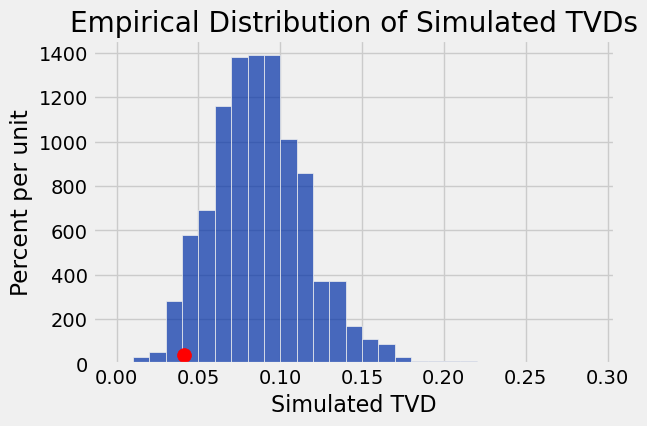

In [34]:
Table().with_column('Simulated TVD', simulated_tvds_results).hist(bins=np.arange(0, 0.3, 0.01))

plots.scatter(observed_tvd_value, 0.4, color='red', s=100)
plots.title("Empirical Distribution of Simulated TVDs")
plots.show()

Since the observed test statistic (TVD between the empirical candy colors proportions and the theoretical factory proportions) is inside the main body of the random sampling distribution, the data is consistent with the null hypothesis. The variations color proportions of the M&M candy bag found in this sample are small enough to be entirely explained by random chance and sampling variability.

In [35]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
p_value = np.count_nonzero(simulated_tvds_results >= observed_tvd_value) / repeats
p_value

0.95599999999999996

### A/B Testing

In A/B testing, we ask whether the two samples are likely from the same population.

**Null hypothesis**: the female and male students have the same average height.

**Alternative hypothesis**: the average height for females should be shorter.

**Test statistic**: the difference between the two sample means

Under the null model, the sampling distribution of the test statistic was generated using a technique called "label shuffling" or "Permutation Shuffling".

In [36]:
students = Table().read_table('student_data.csv')
students

SEX,COLOR,ZIP,MATH,PAPER,CAR,SHOE,AGE,HEIGHT,PETS,SOCIAL
Female,Blue,95403,3,2,2018,6.5,20,61,0,Yes
Female,Other,95401,2,5,2007,6.5,26,61,1,No
Female,Green,95492,1,3,1994,5.5,22,62,4,Yes
Female,Black,95472,3,3,nan,8,19,62,2,Yes
Female,Purple,95409,2,2,1990,7,19,63,3,Yes
Female,Orange,95407,4,3,2016,8.5,37,63,2,Yes
Female,Blue,95401,5,4,2003,8,17,63,5,Yes
Female,Blue,94928,3,3,2012,7.5,18,63,6,Yes
Female,Purple,95403,4,5,nan,8.5,36,63,0,No
Female,Red,95404,2,2,2011,7.5,20,64,7,Yes


In [37]:
sex_and_height = students.select("SEX", "HEIGHT")
sex_and_height

SEX,HEIGHT
Female,61
Female,61
Female,62
Female,62
Female,63
Female,63
Female,63
Female,63
Female,63
Female,64


In [38]:
sex_and_height.group("SEX")

SEX,count
Female,41
Male,33


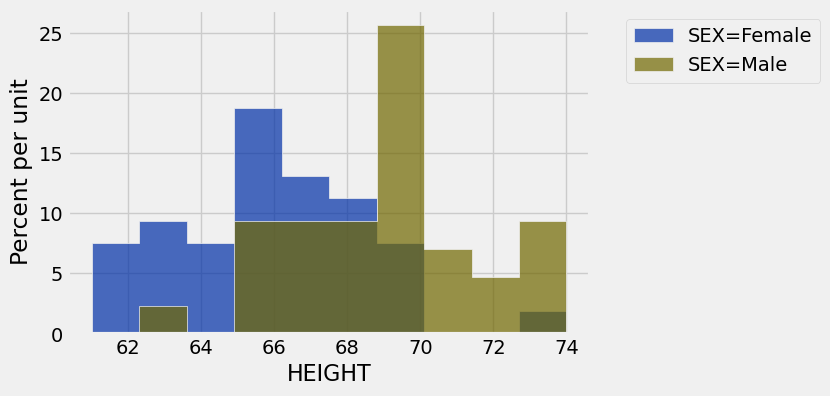

In [39]:
sex_and_height.hist("HEIGHT", group="SEX")

In [40]:
means_table = sex_and_height.group("SEX", np.average)
means_table

SEX,HEIGHT average
Female,65.7805
Male,69.1818


In [41]:
means = means_table.column(1)
observed_difference = means.item(0) - means.item(1)
observed_difference

-3.4013303769401375

In [42]:
def difference_of_means(table, column):
    subtable = table.select(column, "HEIGHT")
    means_table = subtable.group(column, np.average)
    means = means_table.column(1)
    return means.item(0) - means.item(1)

observed_diff = difference_of_means(students, "SEX")
observed_diff

-3.4013303769401375

In [43]:
shuffled_labels = sex_and_height.sample(with_replacement = False).column(0)
original_and_shuffled = sex_and_height.with_columns("Shuffled Label", shuffled_labels)
original_and_shuffled

SEX,HEIGHT,Shuffled Label
Female,61,Female
Female,61,Male
Female,62,Male
Female,62,Male
Female,63,Male
Female,63,Female
Female,63,Male
Female,63,Female
Female,63,Male
Female,64,Female


In [44]:
shuffled_only = original_and_shuffled.select("HEIGHT", "Shuffled Label")
shuffled_group_mean = shuffled_only.group('Shuffled Label', np.average)
shuffled_group_mean

Shuffled Label,HEIGHT average
Female,67.6341
Male,66.8788


In [45]:
difference_of_means(original_and_shuffled, "Shuffled Label")

0.7553584626755452

In [46]:
difference_of_means(original_and_shuffled, "SEX")

-3.4013303769401375

In [57]:
def one_simulated_difference_of_means():
    shuffled_labels = sex_and_height.sample(with_replacement=False).column("SEX")
    shuffled_table = sex_and_height.select("HEIGHT").with_column(
        "Shuffled Label", shuffled_labels)
    return difference_of_means(shuffled_table, "Shuffled Label")   

In [58]:
one_simulated_difference_of_means()

-1.7058388765705956

In [59]:
simulated_differences = make_array()

repeats = 5000
for i in np.arange(repeats):
    new_difference = one_simulated_difference_of_means()
    simulated_differences = np.append(simulated_differences, new_difference) 

Observed Difference: -3.4013303769401375


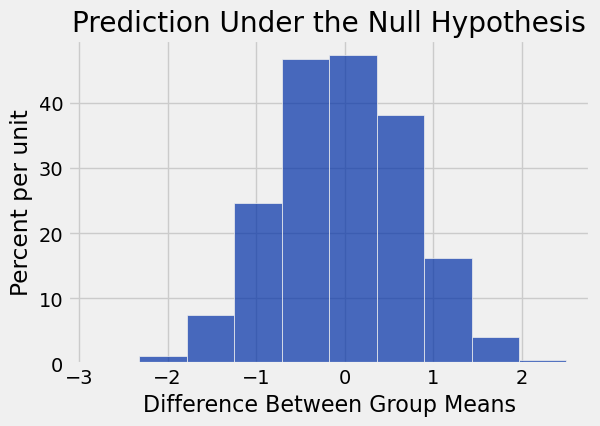

In [60]:
Table().with_column('Difference Between Group Means', simulated_differences).hist()
print('Observed Difference:', observed_difference)
plots.title('Prediction Under the Null Hypothesis');

In [61]:
# p-value >= 0.05 support null hypothesis that is the assumption of random sampling
# p-value < 0.05, the data provides strong evidence against the null hypothesis
p_value = np.count_nonzero(simulated_differences <= observed_difference) / repeats
p_value

0.0